In [43]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics.pairwise import euclidean_distances

## 1. Download dataset

In [2]:
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/asus/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1


In [3]:
os.listdir(path)

['dataset.csv']

In [4]:
df = pd.read_csv(f"{path}/dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.shape

(114000, 21)

In [7]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 2. Data cleaning

In [8]:
# Remove useless columns

df_clean = df.drop(columns=[
    "Unnamed: 0",
    "track_id",
    "artists",
    "album_name",
    "track_name"
])

In [9]:
# Missing values after removing some columns?

df_clean.isnull().sum()

popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [10]:
# Selection of features for cluster

features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = df_clean[features]

In [11]:
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [12]:
X.shape

(114000, 9)

In [13]:
X.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,0.566800,0.641383,-8.258960,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837
std,0.173542,0.251529,5.029337,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750
50%,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000
75%,0.695000,0.854000,-5.003000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


I see that scales are different -> scaling will be necessary

In [14]:
# Save metadata for later

metadata = df[["track_name", "artists", "track_genre"]]

## 3. EDA

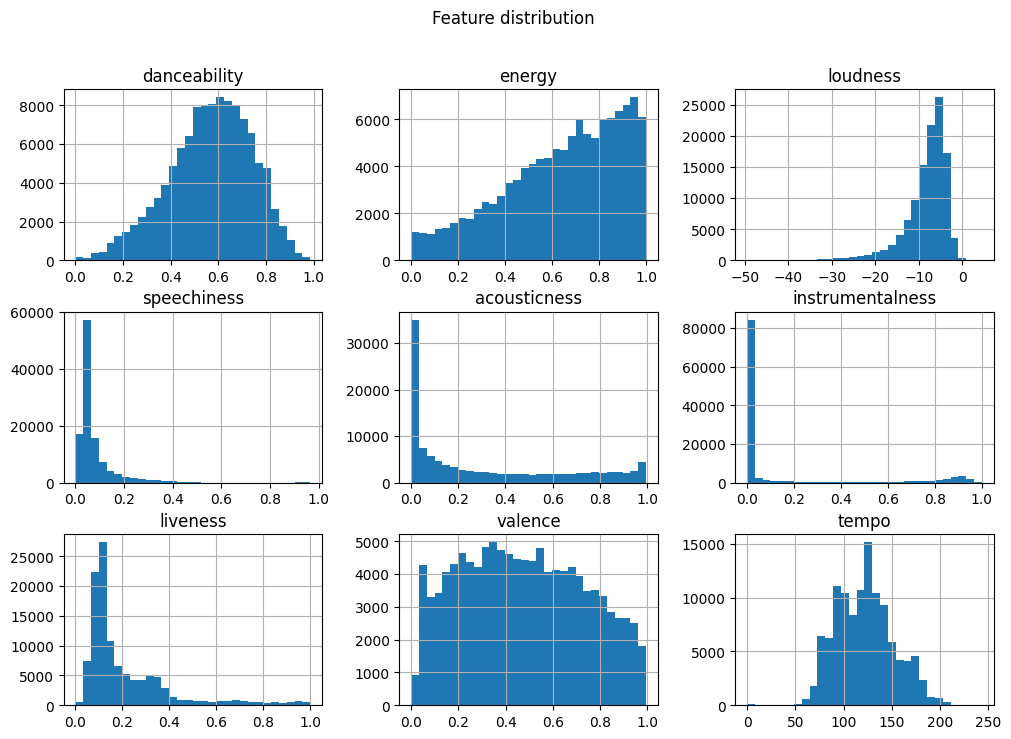

In [15]:
# Features distribution

X.hist(figsize=(12,8), bins=30)
plt.suptitle("Feature distribution")
plt.show()

* Features like "danceability", "energy" and "valence" have values in the whole interval [0,1]
* Features as "speechiness, "loudness", "acousticness", "instrumentalness" and "liveness" are very skewed
* The feature "tempo" has a sort of gaussian distribution

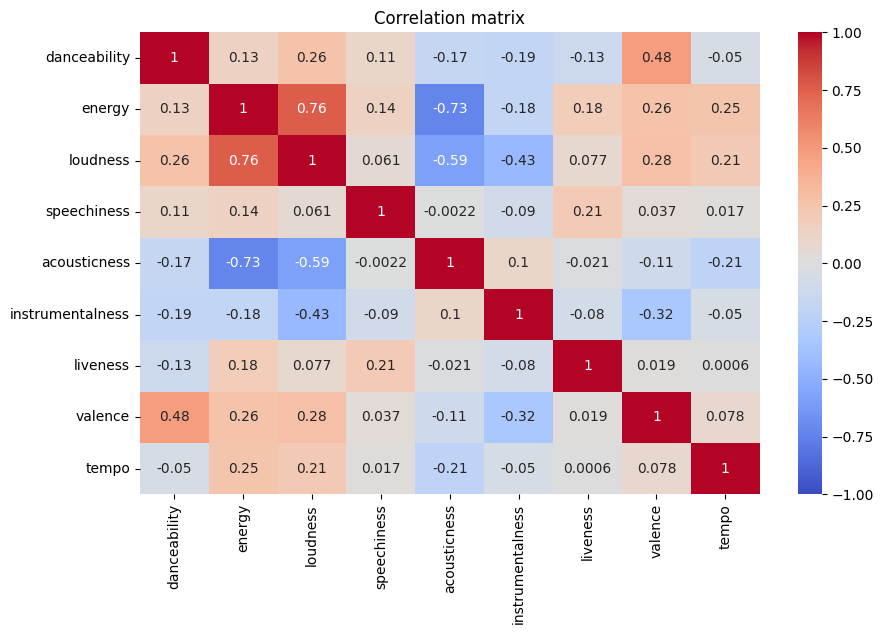

In [16]:
# Correlation matrix

plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

* Some features, as "loudness" and "energy" are very correlated
* Others, as "acousticness and "energy", are very inversely correlated

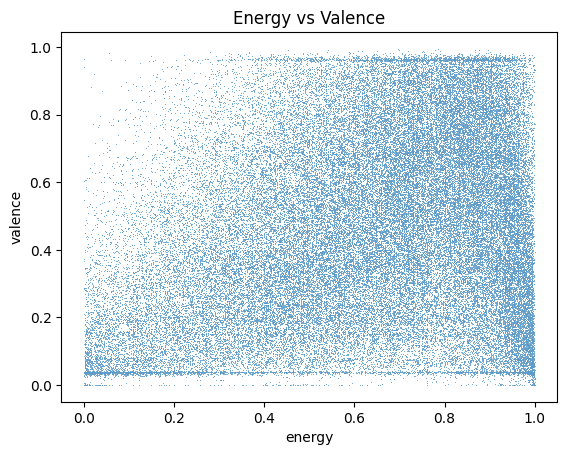

In [17]:
# Key relationships

sns.scatterplot(x="energy", y="valence", data=X, s=0.5)
plt.title("Energy vs Valence")
plt.show()

In general, an higher "energy" value is associated to a higher "valence" (positiveness).

## 4. Feature Scaling

In [18]:
scaler = StandardScaler()

In [19]:
# Sampling: it is necessary because otherwise the linkage matrix would be huge and impossible to compute on my laptop

sample_size = 10000

X_sample = X.sample(n=sample_size, random_state=42)
X_scaled_sample = scaler.fit_transform(X_sample)

In [20]:
# Check

print(np.mean(X_scaled_sample, axis=0))
print(np.std(X_scaled_sample, axis=0))

[-1.42819090e-16 -2.76401124e-16 -1.71951342e-16  1.27897692e-17
  1.81188398e-17 -3.76587650e-17 -9.57456336e-17  6.39488462e-17
  3.41060513e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Hierchical Clustering

In [21]:
# Build the linkage matrix

Z = linkage(X_scaled_sample, method="ward")

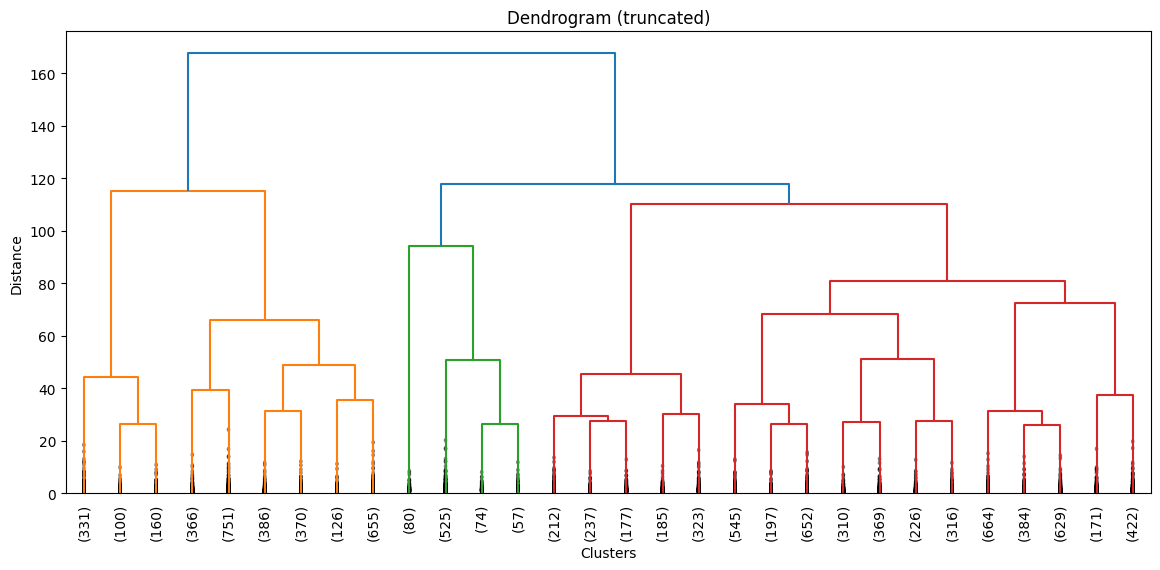

In [23]:
# Dendrogram "truncated" to make it readable

plt.figure(figsize=(14,6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title("Dendrogram (truncated)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

To choose clusters, I need to consider the grouping "before" big vertical jumps. 

I decide to group data in 5 clusters, to avoid over and under fragmentantion.

## 6. Clusters creations

In [24]:
# Create clusters

t = 5
clusters = fcluster(Z, t=t, criterion="maxclust")

In [26]:
# Connect clusters to data

X_sample = X_sample.copy()
X_sample["cluster"] = clusters

In [27]:
X_sample

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
113186,0.369,0.598,-6.984,0.0304,0.00511,0.000000,0.1760,0.0466,148.014,5
42819,0.171,0.997,-3.586,0.1180,0.00521,0.801000,0.4200,0.0294,122.223,4
59311,0.173,0.803,-10.071,0.1440,0.61300,0.001910,0.1950,0.0887,75.564,2
91368,0.683,0.511,-5.598,0.0279,0.40600,0.000197,0.1110,0.5980,109.991,2
61000,0.555,0.941,-3.294,0.0481,0.48400,0.000000,0.2660,0.8130,92.487,2
...,...,...,...,...,...,...,...,...,...,...
108175,0.632,0.702,-4.496,0.0228,0.35600,0.000000,0.2470,0.7890,99.955,2
67100,0.756,0.646,-5.795,0.3190,0.15200,0.000018,0.1080,0.4290,176.088,5
97452,0.729,0.752,-4.100,0.0339,0.66800,0.000000,0.2190,0.6380,113.865,5
96430,0.380,0.783,-7.356,0.0454,0.18800,0.000000,0.9650,0.5350,137.020,3


In [28]:
# Cluster distribution

X_sample["cluster"].value_counts().sort_index()

cluster
1     591
2    2654
3     736
4    1134
5    4885
Name: count, dtype: int64

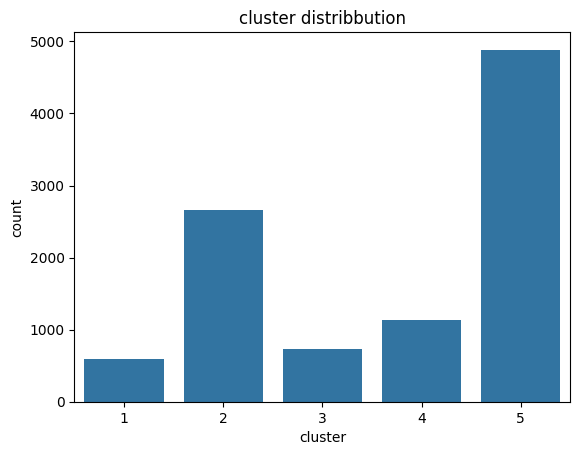

In [29]:
sns.countplot(x="cluster", data=X_sample)
plt.title("cluster distribbution")
plt.show()

Some clusters are more "populated", indicating the presence of dominant music groups.

In [30]:
# Add metadata

X_sample["genre"] = df_clean.loc[X_sample.index, "track_genre"]

In [31]:
X_sample

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster,genre
113186,0.369,0.598,-6.984,0.0304,0.00511,0.000000,0.1760,0.0466,148.014,5,world-music
42819,0.171,0.997,-3.586,0.1180,0.00521,0.801000,0.4200,0.0294,122.223,4,grindcore
59311,0.173,0.803,-10.071,0.1440,0.61300,0.001910,0.1950,0.0887,75.564,2,iranian
91368,0.683,0.511,-5.598,0.0279,0.40600,0.000197,0.1110,0.5980,109.991,2,rock
61000,0.555,0.941,-3.294,0.0481,0.48400,0.000000,0.2660,0.8130,92.487,2,j-idol
...,...,...,...,...,...,...,...,...,...,...,...
108175,0.632,0.702,-4.496,0.0228,0.35600,0.000000,0.2470,0.7890,99.955,2,tango
67100,0.756,0.646,-5.795,0.3190,0.15200,0.000018,0.1080,0.4290,176.088,5,latin
97452,0.729,0.752,-4.100,0.0339,0.66800,0.000000,0.2190,0.6380,113.865,5,sertanejo
96430,0.380,0.783,-7.356,0.0454,0.18800,0.000000,0.9650,0.5350,137.020,3,samba


## 8. Cluster interpretation

In [33]:
# Clusters profile

cluster_profile = X_sample.groupby("cluster").mean(numeric_only=True)
cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
1,0.385748,0.204451,-19.395856,0.052325,0.858671,0.835372,0.133822,0.242441,105.692655
2,0.554401,0.435496,-10.191416,0.046143,0.588297,0.018602,0.154384,0.448280,112.728451
3,0.514279,0.705253,-8.521090,0.174480,0.406863,0.075058,0.756908,0.499086,118.380360
4,0.566484,0.763184,-8.073835,0.074885,0.106272,0.744384,0.189413,0.328272,128.978942
5,0.595449,0.772819,-5.741805,0.099637,0.140454,0.019555,0.185068,0.543888,129.029704


Possible interpretation:

* Cluster 1: Ambient/Focus $\rightarrow$ low energy, loudness and valence, high acousticness and instrumentalness
* Cluster 2: Chill/Acoustic $\rightarrow$ low-medium energy and valence, high acousticness and low instrumentalness
* Cluster 3: Live/Energy $\rightarrow$ high energy, speechness and liveness, and medium valence
* Cluster 4: Instrumental $\rightarrow$ high energy, instrumentalness, low scousticness and valence
* Cluster 5: Mainstream/Hits $\rightarrow$ high energy, danceability, loudness and valence, low instrumentalness. This is the biggest cluster.

Clusters are created on the basis on auditive characteristics and can group more musical genres. The dimensions "valence" (mood) and "energy" (intensity) are the principal properties for musical segmentation.

In [38]:
X_sample.groupby("cluster")["genre"].value_counts().head(15)

cluster  genre      
1        classical      59
         ambient        56
         new-age        50
         sleep          46
         piano          43
         disney         37
         guitar         37
         idm            30
         iranian        26
         study          25
         tango          24
         german         20
         opera          14
         anime          13
         world-music    11
Name: count, dtype: int64

For example, in Cluster 1 we see that there are items from different musical genres, but they share acoustic properties.

## 9. Mini recommender system

In [42]:
# Prepare data

df_sample = X_sample.copy()

df_sample["track_name"] = df.loc[X_sample.index, "track_name"]
df_sample["artist"] = df.loc[X_sample.index, "artists"]
df_sample["genre"] = df.loc[X_sample.index, "track_genre"]

In [48]:
# Function to recomment song
# Given a song, find similar songs (based on euclidean distance) in the same cluster

def recommend_songs(track_name, artist, df, features, n=5):

    song = df[(df["track_name"].str.lower() == track_name.lower()) & (df["artist"].str.lower() == artist.lower())]

    if song.empty:
        return "Song not found"

    cluster = song["cluster"].values[0]
    cluster_songs = df[df["cluster"] == cluster]

    # Distance
    distances = euclidean_distances(song[features], cluster_songs[features])

    cluster_songs = cluster_songs.copy()
    cluster_songs["distance"] = distances[0]

    return cluster_songs.sort_values("distance").iloc[1:n+1][["track_name", "artist", "genre", "distance"]]

In [49]:
# Song "Comedy" from "Gen Hoshino"

recommend_songs("Comedy", "Gen Hoshino", df_sample, features, n=5)

,track_name,artist,genre,distance
30637,"Family (feat. Bebe Rexha, Ty Dolla $ign & A Bo...",David Guetta;Bebe Rexha;Ty Dolla $ign;A Boogie...,edm,0.403587
30014,Family,David Guetta;Bebe Rexha;Ty Dolla $ign;A Boogie...,edm,0.403587
89741,Mi Necesidad,Bayron Fire,reggaeton,0.459945
80471,Vibe,Diljit Dosanjh,pop-film,0.532746
56686,PS5 - Nintendo Switch Version,salem ilese,indie-pop,0.606202


These are the top 5 songs closer to the song "Comedy" and inside the same cluster.